# Knowledge Distillation

- distillation using forward KL divergence on token distributions (logits)
- teacher outputs are truncated with top-p-k (p>=.95, k<=100) before forming the target distribution to save storage space
- KD loss weight λ follows a **warmup → stable → decay** schedule (warmup-stable-decay by Hu et al)
- learning rate follows WSD pattern to promote maximum learning in stable period w/ teacher model and decay towards student at end (Peng et al)

In [1]:
import os
import math
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from transformers import GPT2LMHeadModel

from model import GPT, GPTConfig

device      = 'cuda' if torch.cuda.is_available() else 'cpu'
device_type = 'cuda' if 'cuda' in device else 'cpu'
dtype       = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float32
print(f"device: {device}  |  dtype: {dtype}")

/home/grant/miniforge3/envs/nanogpt_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda  |  dtype: torch.bfloat16


### Parameters

In [2]:
# ── Data ──────────────────────────────────────────────────────────────────────
block_size       = 1024
fineweb_shard    = os.path.join('edu_fineweb10B',       'edufineweb_train_000001.npy')
commonpile_shard = os.path.join('common_pile_filtered', 'commonpile_train_000001.npy')
val_data         = np.load(os.path.join('edu_fineweb10B', 'edufineweb_val_000000.npy'))

# loads validation data
def get_batch():
    ix = torch.randint(len(val_data) - block_size, (batch_size,))
    x  = torch.stack([torch.from_numpy(val_data[i:i+block_size].astype(np.int64))     for i in ix])
    y  = torch.stack([torch.from_numpy(val_data[i+1:i+1+block_size].astype(np.int64)) for i in ix])
    return x.to(device), y.to(device)

# ── Schedule (10% warmup, 89% stable, 1% decay) ───────────────────────────────
max_iters    = 5000
warmup_iters = int(0.10 * max_iters)
stable_iters = int(0.89 * max_iters)
decay_iters  = int(0.01 * max_iters)

# ── Distillation hyper-params ─────────────────────────────────────────────────
top_k = 1000
top_p = 0.95

# ── Optimizer ─────────────────────────────────────────────────────────────────
batch_size = 3
max_lr     = 5e-3
min_lr     = 5e-4

# ── Paths ─────────────────────────────────────────────────────────────────────
distill_dir = f'distill/distill_data_{max_iters}'
out_dir     = 'distill/distill-gpt2-med'
mini_shard_path = os.path.join(distill_dir, 'mini_shard.npy')

# ── Eval ──────────────────────────────────────────────────────────────────────
eval_interval = 500
eval_iters    = 50 # number of sub-datasets to split valid dataset into to eval isn't over whole shard

os.makedirs(distill_dir, exist_ok=True)
os.makedirs(out_dir,     exist_ok=True)

In [3]:
def create_mini_shard(cp_shard_path, fw_shard_path, out_path, num_samples):
    """
    Sample num_samples chunks from commonpile (1/3) and fineweb (2/3) using
    mmap — only sampled pages are read from disk. Saves as a flat token array.
    Idempotent: skips if out_path already exists.
    """
    if os.path.exists(out_path):
        print(f"  skip (exists): {out_path}")
        return

    cp_data = np.load(cp_shard_path, mmap_mode='r')
    fw_data = np.load(fw_shard_path, mmap_mode='r')

    n_cp = num_samples // 3
    n_fw = num_samples - n_cp

    cp_ids = np.random.choice(len(cp_data) // block_size, size=n_cp, replace=False)
    fw_ids = np.random.choice(len(fw_data) // block_size, size=n_fw, replace=False)

    cp_chunks = np.array([cp_data[i*block_size:(i+1)*block_size] for i in cp_ids])
    fw_chunks = np.array([fw_data[i*block_size:(i+1)*block_size] for i in fw_ids])

    mini = np.concatenate([cp_chunks, fw_chunks]).reshape(-1)
    np.save(out_path, mini)
    print(f"Saved mini shard: {n_cp + n_fw:,} chunks ({n_cp} CP + {n_fw} FW)  →  {out_path}")


def create_cp_mini_shard(cp_shard_path, out_path, num_samples):
    """
    Sample num_samples chunks from only commonpile using
    mmap — only sampled pages are read from disk. Saves as a flat token array.
    Idempotent: skips if out_path already exists.
    """
    if os.path.exists(out_path):
        print(f"  skip (exists): {out_path}")
        return

    cp_data = np.load(cp_shard_path, mmap_mode='r')
    cp_ids = np.random.choice(len(cp_data) // block_size, size=num_samples, replace=False)
    cp_chunks = np.array([cp_data[i*block_size:(i+1)*block_size] for i in cp_ids])

    mini = cp_chunks.reshape(-1)
    np.save(out_path, mini)
    print(f"Saved mini shard: {num_samples}  →  {out_path}")


def load_shard_distill(path):
    return (
        np.load(path,                                 mmap_mode='r'),
        np.load(path.replace('.npy', '_tidx.npy'),  mmap_mode='r'),
        np.load(path.replace('.npy', '_tprob.npy'), mmap_mode='r'),
    )

## Helper Functions

- filtering for p and k of teacher logits
- computing WSD KD divergence weighting
- computing learning rate based on WSD
- precompute for teacher for offline distillation (don't need student and teacher running on GPU at once)

In [ ]:
def top_p_k_filter(logits: torch.Tensor, top_k: int = 100, top_p: float = 0.95):
    """
    Apply top-p then top-k filtering without sorting the full vocab.
    Pre-selects top pre_k=top_k*10 tokens via topk (already descending),
    applies top-p on that subset, then trims to top_k.
    Returns filtered logits and vocab indices, both [B, T, pre_k].
    """
    pre_k = min(top_k * 10, logits.size(-1))
    vals, idx = torch.topk(logits, pre_k, dim=-1)          # [B, T, pre_k] descending

    probs      = F.softmax(vals, dim=-1)
    cumulative = torch.cumsum(probs, dim=-1)
    remove     = (cumulative - probs) >= top_p
    vals       = vals.masked_fill(remove, float('-inf'))

    kth_val = torch.topk(vals, top_k, dim=-1).values[..., -1, None]
    return vals.masked_fill(vals < kth_val, float('-inf')), idx


def kd_lambda(step: int, warmup: int, stable: int, decay: int) -> float:
    """
    Returns scalar for warmup-stable-decay (WSD)
    Used for KD loss weight and learning rate
    1. warmup ramps linearly from 0-1
    2. stable regime stays at 1 (teacher-only contribution to loss)
    3. cosine decay from 1 to 0
    """
    if step < warmup:
        return step / warmup
    if step < warmup + stable:
        return 1.0
    progress = min(1.0, (step - warmup - stable) / decay)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

def wsd_lr(lam:float, max_lr: float, min_lr: float) -> float:
    """
    WSD-LR: warmup-stable-decay learning rate schedule.
    Uses the same phase boundaries as WSD lam but mapped to min/max lr
    """
    # map from 0-1 to min_lr to max_lr
    return min_lr + (max_lr-min_lr) * lam

def kd_loss_from_sparse(
    student_logits: torch.Tensor,
    top_idx: torch.Tensor,
    top_probs: torch.Tensor,
) -> torch.Tensor:
    """
    Forward KL divergence from pre-computed sparse teacher outputs.
    Avoids reconstructing the full dense teacher distribution.

    Args:
        student_logits: [B, T, 50304]
        top_idx:        [B, T, k]  int64  — vocab indices of kept tokens
        top_probs:      [B, T, k]  float  — renormalized teacher probs at those indices
    """
    s_log      = F.log_softmax(student_logits[..., :TEACHER_V], dim=-1)  # [B, T, V]
    s_log_at_k = s_log.gather(-1, top_idx)                               # [B, T, k]
    t_log_at_k = top_probs.clamp(min=1e-10).log()
    kl = (top_probs * (t_log_at_k - s_log_at_k)).sum(-1)                 # [B, T]
    return kl.mean()

def rev_kd_loss_from_sparse(
    student_logits: torch.Tensor,
    top_idx: torch.Tensor,
    top_probs: torch.Tensor,
) -> torch.Tensor:
    """
    Reverse KL divergence from pre-computed sparse teacher outputs.
    Zero-seeking behavior instead of mean-seeking

    Args:
        student_logits: [B, T, 50304]
        top_idx:        [B, T, k]  int64  — vocab indices of kept tokens
        top_probs:      [B, T, k]  float  — renormalized teacher probs at those indices
    """
    s_log      = F.log_softmax(student_logits[..., :TEACHER_V], dim=-1)  # [B, T, V]
    s_log_at_k = s_log.gather(-1, top_idx)                               # [B, T, k]
    s_prob_at_k = s_log_at_k.exp()
    t_log_at_k = top_probs.clamp(min=1e-10).log()
    kl = (s_prob_at_k * (s_log_at_k - t_log_at_k)).sum(-1)                 # [B, T]
    return kl.mean()

def precompute_teacher_sparse(shard_path, teacher, top_k, top_p, block_size, batch_size):
    """
    Run the teacher on every non-overlapping block_size chunk of a shard and
    save the sparse (top_idx, top_probs) outputs as companion .npy files.

    Companion files written next to each shard:
      <shard>_tidx.npy   uint16  [num_chunks, block_size, top_k]  vocab indices
      <shard>_tprob.npy  float16 [num_chunks, block_size, top_k]  renorm'd probs

    uint16 covers 0-65535, sufficient for GPT-2 vocab (50257).
    Idempotent: skips shard if both companion files already exist.
    """
    tidx_path  = shard_path.replace('.npy', '_tidx.npy')
    tprob_path = shard_path.replace('.npy', '_tprob.npy')
    done_path  = shard_path.replace('.npy', '_done.txt')
    prog_path  = shard_path.replace('.npy', '_prog.txt')

    if os.path.exists(done_path):
        print(f"  skip (complete): {os.path.basename(shard_path)}")
        return

    data       = np.load(shard_path, mmap_mode='r')
    num_chunks = len(data) // block_size

    # output arrays live ON DISK, not in RAM
    mode = 'r+' if os.path.exists(tidx_path) else 'w+'
    all_idx  = np.lib.format.open_memmap(tidx_path,  mode=mode, dtype=np.uint16,
                                         shape=(num_chunks, block_size, top_k))
    all_prob = np.lib.format.open_memmap(tprob_path, mode=mode, dtype=np.float16,
                                         shape=(num_chunks, block_size, top_k))

    start = 0
    if os.path.exists(prog_path):
        start = int(open(prog_path).read().strip())
        print(f"  resuming at chunk {start}/{num_chunks}")

    for b_start in range(start, num_chunks, batch_size):
        b_end  = min(b_start + batch_size, num_chunks)
        chunks = np.stack([data[j*block_size:(j+1)*block_size] for j in range(b_start, b_end)])
        x      = torch.from_numpy(chunks.astype(np.int64)).to(device)

        with torch.no_grad(), torch.amp.autocast(device_type=device_type, dtype=dtype):
            logits = teacher(input_ids=x).logits

        vals, pre_idx = top_p_k_filter(logits.float(), top_k, top_p)
        probs      = F.softmax(vals, dim=-1)
        tv, ti_loc = torch.topk(probs, top_k, dim=-1)
        ti         = pre_idx.gather(-1, ti_loc)

        all_idx [b_start:b_end] = ti.cpu().numpy().astype(np.uint16)
        all_prob[b_start:b_end] = tv.cpu().numpy().astype(np.float16)

        del logits, vals, pre_idx, probs, tv, ti_loc, ti, x

        if b_start % (batch_size * 50) == 0:
            all_idx.flush(); all_prob.flush()
            with open(prog_path, 'w') as f: f.write(str(b_end))
            if device_type == 'cuda': torch.cuda.empty_cache()
            print(f"  {os.path.basename(shard_path)}: {b_end}/{num_chunks} chunks", end='\r')

    all_idx.flush(); all_prob.flush()
    with open(done_path, 'w') as f: f.write('done')
    print(f"\n  saved: {os.path.basename(tidx_path)}, {os.path.basename(tprob_path)}")


def get_train_batch(data, tidx, tprob):
    """
    Aligned-chunk sampling from whichever shard is passed in.
    Chunk index i maps directly to tidx[i] / tprob[i], keeping tokens and
    sparse teacher distribution in sync across shards.
    Returns x, y (tokens) and ti, tp (sparse teacher distribution).
    """
    num_chunks = len(data) // block_size
    cids = torch.randint(num_chunks-1, (batch_size,)).tolist()
    x  = np.stack([data[i*block_size  :(i+1)*block_size  ] for i in cids]).astype(np.int64)
    y  = np.stack([data[i*block_size+1:(i+1)*block_size+1] for i in cids]).astype(np.int64)
    ti = np.stack([tidx [i] for i in cids]).astype(np.int64)
    tp = np.stack([tprob[i] for i in cids]).astype(np.float32)
    return (torch.from_numpy(x).to(device),  torch.from_numpy(y).to(device),
            torch.from_numpy(ti).to(device), torch.from_numpy(tp).to(device))

## Load Teacher

Loads larger LLM and precomputes logits. Grabs sparse representations to avoid memory issues

In [5]:
TEACHER_V = 50257   # GPT-2 vocab; student uses 50304

In [ ]:
# NOTE: Only run if you need to use the teacher, not if using precomputed mini shards
# ── Teacher (GPT-2 medium, frozen) ────────────────────────────────────────────
teacher = GPT2LMHeadModel.from_pretrained('gpt2-medium', torch_dtype=dtype).to(device).eval()
for p in teacher.parameters():
    p.requires_grad_(False)
print(f"Teacher: {sum(p.numel() for p in teacher.parameters())/1e6:.2f}M params")

Loading weights: 100%|██████████| 292/292 [00:00<00:00, 789.21it/s]


Teacher: 354.82M params


: 

In [ ]:
# NOTE: Only run if you need to use the teacher, not if using precomputed mini shards
create_cp_mini_shard(commonpile_shard, mini_shard_path, num_samples=max_iters * batch_size)
precompute_teacher_sparse(mini_shard_path, teacher, top_k, top_p, block_size, batch_size)

teacher.cpu()
torch.cuda.empty_cache()
print("Teacher unloaded from GPU")

Saved mini shard: 15000  →  distill/distill_data_5000/mini_shard.npy


## Load student model

In [ ]:
# NOTE: Only run if you need to load the student checkpoint
# Load checkpoint from huggingface, if needed
from huggingface_hub import snapshot_download
model_dir = snapshot_download(
    repo_id="QUdie/UdieGPT", 
    local_dir="./model_chkpt"
)

Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 2553.87it/s]


In [ ]:
# ── Student (custom GPT loaded from checkpoint) ───────────────────────────────
model_dir="./model_chkpt"
ckpt_path  = f'{model_dir}/checkpoint.pt'
checkpoint = torch.load(ckpt_path, map_location=device)

checkpoint_model_args = checkpoint['model_args']
gptconf = GPTConfig(**checkpoint_model_args)
student = GPT(gptconf)

state_dict = checkpoint['model']
prefix = '_orig_mod.'
for k in list(state_dict):
    if k.startswith(prefix):
        state_dict[k[len(prefix):]] = state_dict.pop(k)
student.load_state_dict(state_dict)
student = student.to(device).to(dtype)
student.train()
print(f"Student: {student.get_num_params()/1e6:.2f}M params")

grad_clip = 1.0
optimizer = AdamW(student.parameters(), lr=max_lr, weight_decay=0.1, betas=(0.9, 0.95))

/tmp/ipykernel_38987/2009503557.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location=device)


number of parameters: 95.27M
Student: 95.27M params


### Train student

In [ ]:
# ── Training loop for student ───────────────────────────────────────────────────────
log_steps, log_train, log_val, log_lam, log_lr = [], [], [], [], []
cur_data, cur_tidx, cur_tprob = load_shard_distill(mini_shard_path)
print(f"Loaded: {len(cur_data):,} tokens  |  {len(cur_data) // block_size:,} chunks")

for step in range(max_iters):
    student.train()

    # learning rate & KDL weighting
    lam = kd_lambda(step, warmup_iters, stable_iters, decay_iters)
    lr  = wsd_lr(lam, max_lr, min_lr)
    for pg in optimizer.param_groups:
        pg['lr'] = lr

    x, y, ti, tp = get_train_batch(cur_data, cur_tidx, cur_tprob)

    with torch.amp.autocast(device_type=device_type, dtype=dtype):
        student_logits, ce = student(x, y)
        kd   = rev_kd_loss_from_sparse(student_logits, ti, tp)
        loss = lam * kd + (1.0 - lam) * ce      # diff between teacher and diff between truth

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(student.parameters(), grad_clip)
    optimizer.step()

    if step % 100 == 0:
        print(f"step {step:5d} | loss {loss.item():.4f} | ce {ce.item():.4f} "
              f"| kd {kd.item():.4f} | α {lam:.3f} | lr {lr:.2e}")

    if step % eval_interval == 0:
        student.eval()
        v_losses = []
        with torch.no_grad():
            for _ in range(eval_iters):
                xv, yv = get_batch()
                with torch.amp.autocast(device_type=device_type, dtype=dtype):
                    _, vl = student(xv, yv)
                v_losses.append(vl.item())
        log_steps.append(step)
        log_train.append(loss.item())
        log_val.append(float(np.mean(v_losses)))
        log_lam.append(lam)
        log_lr.append(lr)
        print(f"  → val_loss {log_val[-1]:.4f}")

torch.save(
    {'model': student.state_dict(), 'model_args': vars(student.config)},
    os.path.join(out_dir, 'ckpt.pt'),
)
print(f"\nSaved distilled checkpoint → {out_dir}/ckpt.pt")

Loaded: 3,072,000 tokens  |  3,000 chunks
step     0 | loss 2.5855 | ce 2.5855 | kd 0.7157 | α 0.000 | lr 3.00e-05
  → val_loss 3.2856
step   100 | loss 0.6234 | ce 3.0266 | kd 0.6234 | α 1.000 | lr 3.00e-04
step   200 | loss 0.5085 | ce 1.9607 | kd 0.5085 | α 1.000 | lr 3.00e-04
step   300 | loss 0.5957 | ce 3.0538 | kd 0.5957 | α 1.000 | lr 3.00e-04
step   400 | loss 0.6340 | ce 3.0299 | kd 0.6340 | α 1.000 | lr 3.00e-04
step   500 | loss 0.7639 | ce 3.4423 | kd 0.7639 | α 1.000 | lr 3.00e-04
  → val_loss 3.4178
step   600 | loss 0.5591 | ce 3.2509 | kd 0.5591 | α 1.000 | lr 3.00e-04
step   700 | loss 0.5435 | ce 3.1046 | kd 0.5435 | α 1.000 | lr 3.00e-04
step   800 | loss 0.5198 | ce 2.6380 | kd 0.5198 | α 1.000 | lr 3.00e-04
step   900 | loss 0.5561 | ce 2.4457 | kd 0.5561 | α 1.000 | lr 3.00e-04

Saved distilled checkpoint → distill/distill-gpt2-med/ckpt.pt


## Show results

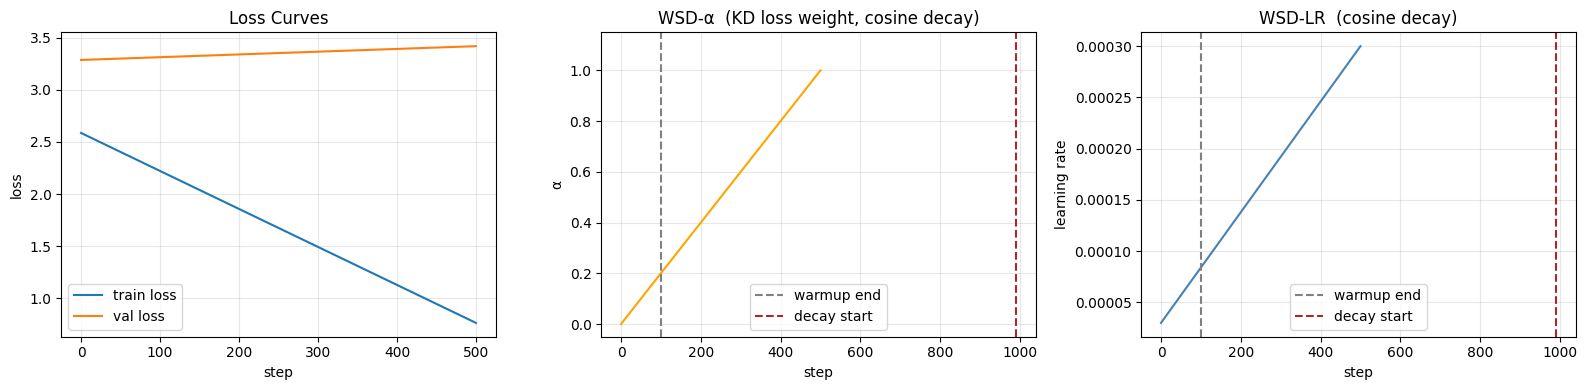

Saved → distill/distill-gpt2-med/distill_curves.png


In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curves
axes[0].plot(log_steps, log_train, label='train loss')
axes[0].plot(log_steps, log_val,   label='val loss')
axes[0].set_xlabel('step'); axes[0].set_ylabel('loss')
axes[0].set_title('Loss Curves'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# α schedule
axes[1].plot(log_steps, log_lam, color='orange')
axes[1].axvline(warmup_iters,                label='warmup end',  color='gray',  linestyle='--')
axes[1].axvline(warmup_iters + stable_iters, label='decay start', color='brown', linestyle='--')
axes[1].set_xlabel('step'); axes[1].set_ylabel('α')
axes[1].set_title('WSD-α  (KD loss weight, cosine decay)')
axes[1].set_ylim(-0.05, 1.15); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# LR schedule
axes[2].plot(log_steps, log_lr, color='steelblue')
axes[2].axvline(warmup_iters,                label='warmup end',  color='gray',  linestyle='--')
axes[2].axvline(warmup_iters + stable_iters, label='decay start', color='brown', linestyle='--')
axes[2].set_xlabel('step'); axes[2].set_ylabel('learning rate')
axes[2].set_title('WSD-LR  (cosine decay)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
save_path = os.path.join(out_dir, 'distill_curves.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {save_path}")

In [ ]:
for i in range(len(log_lam)):
    print(f'{i} | {log_lam[i]} | {log_lr[i]}')

0 | 0.0 | 3e-05
1 | 1.0 | 0.0003
